# Taller de Análisis de Datos
**Curso: Taller de investigación III**  
**Integrantes: Valentina y Yostin**  
**Fecha: Octubre 7 2025**

---

## 1. Nivel de medición de las variables


In [10]:
#Libreriras necesarias (pandas para la base de datos y matplotlib para las gráficas)
import pandas as pd
import matplotlib.pyplot as plt

# Usamos pandas para ver todas las columnas
pd.set_option("display.max_columns", None)

# Aqui se cargan los datos
df = pd.read_excel("data/psyco.xlsx")
df.head()


,age,gender,occupation,line_of_work,time_bp,time_dp,easeof_online,home_env,prefer
0,19-25,Male,Student in College,NaN,7,5,3,3,Complete Physical Attendance
1,12-18,Male,Student in School,NaN,7,11,4,2,Complete Physical Attendance
2,19-25,Male,Student in College,NaN,7,7,2,2,Complete Physical Attendance
3,19-25,Male,Student in College,NaN,7,7,3,1,Complete Physical Attendance
4,19-25,Female,Student in College,NaN,7,7,2,2,Complete Physical Attendance


### Análisis del nivel de medición de todas las variables de la base de datos
- age = Ordinal (grupos etarios con orden)
- gender = Nominal (categorías sin orden)
- occupation = Nominal
- line_of_work = Nominal
- time_bp = Razón (horas con cero absoluto)
- time_dp = Razón
- easeof_online = Ordinal (escala 1–5)
- home_env = Ordinal (escala 1–5)
- prefer = Nominal


## 2. Estadísticas descriptivas
Para variables:
- Categóricas = calcular proporciones.
- Numéricas = calcular media, mediana, desviación estándar, varianza, mínimo, máximo.


In [ ]:
#estadísticos descriptivos para variables numéricos

#columnas numéricas relevantes:
#time_bp= tiempo trabajado antes de la pandemia
#time_dp= tiempo trabajado durante la pandemia
desc_num = df[["time_bp", "time_dp"]].describe().T  # la funcion describe() genera count, mean, std, min, 25%, 50%, 75%, max
#donde los datos que necesitamos son =
#   - mean: media (promedio aritmético)
#   - std: desviación estándar (dispersión respecto a la media)
#   - min: valor mínimo observado
#   - 50%: mediana (Q2)
#   - max: valor máximo observado
# Agregamos la varianza manualmente, porque la funcion no la incluye
desc_num["varianza"] = df[["time_bp", "time_dp"]].var()

# Agregamos la mediana (el percentil 50), de forma explícita
desc_num["mediana"] = df[["time_bp", "time_dp"]].median()

# Tabla final con estadísticas descriptivas
desc_num



,count,mean,std,min,25%,50%,75%,max,varianza,mediana
time_bp,1175.0,7.415319,2.005385,4.0,5.0,7.0,9.0,12.0,4.021571,7.0
time_dp,1175.0,7.971915,2.657007,4.0,5.0,9.0,9.0,12.0,7.059688,9.0


In [ ]:
#estadísticos descriptivos para variables ordinaleles

#variables ordinales de la encuesta:
#   - easeof_online = qué tan fácil fue adaptarse al trabajo en línea (escala 1-5)
#   - home_env = nivel de comodidad trabajando en casa (escala 1-5)
#tal como en las variables numericas:
#   - mean: media (promedio aritmético)
#   - std: desviación estándar (dispersión respecto a la media)
#   - min: valor mínimo observado
#   - 50%: mediana (Q2)
#   - max: valor máximo observado
desc_ord = df[["easeof_online", "home_env"]].describe().T  

desc_ord["varianza"] = df[["easeof_online", "home_env"]].var()

desc_ord["mediana"] = df[["easeof_online", "home_env"]].median()

# Mostramos la tabla con los resultados
desc_ord



,count,mean,std,min,25%,50%,75%,max,varianza,mediana
easeof_online,1175.0,2.533617,1.267609,1.0,1.0,2.0,4.0,5.0,1.606833,2.0
home_env,1175.0,2.752340,1.235799,1.0,2.0,3.0,4.0,5.0,1.527199,3.0


Aunque las variables easeof_online y home_env son ordinales, en este análisis se tratan como numéricas debido a que están medidas en una escala de 1 a 5.  
Esto permite calcular estadísticos como la media, la desviación estándar y la varianza para describir tendencias y dispersión en las respuestas, además de las proporciones por categoría. 

In [ ]:
# estadísticos descriptivos para variables categóricas

# Definimos la lista de variables categóricas en la base de datos:
#   - age: grupo etario (categoría ordinal)
#   - gender: género (categoría nominal)
#   - occupation: ocupación principal (categoría nominal)
#   - line_of_work: sector laboral (categoría nominal)
#   - prefer: preferencia de modalidad (casa o presencial, categoría nominal)
categoricas = ["age", "gender", "occupation", "line_of_work", "prefer"]

# Para cada variable categórica:
#   - value_counts(normalize=True) calcula la frecuencia relativa (proporción de cada categoría)
#   - normalize=True asegura que los valores se expresen como porcentajes (suman 1)
#   - print() muestra los resultados en consola, precedidos por el nombre de la variable
for col in categoricas:
    print(f"\nProporciones de {col}:")
    print(df[col].value_counts(normalize=True))




Proporciones de age:
age
19-25    0.293617
26-32    0.222128
40-50    0.154043
50-60    0.144681
33-40    0.086809
12-18    0.062979
60+      0.035745
Name: proportion, dtype: float64

Proporciones de gender:
gender
Male                 0.552340
Female               0.440851
Prefer not to say    0.006809
Name: proportion, dtype: float64

Proporciones de occupation:
occupation
Working Professional                                    0.407660
Student in College                                      0.304681
Entrepreneur                                            0.101277
Homemaker                                               0.069787
Medical Professional aiding efforts against COVID-19    0.062128
Currently Out of Work                                   0.037447
Student in School                                       0.015319
Retired/Senior Citizen                                  0.001702
Name: proportion, dtype: float64

Proporciones de line_of_work:
line_of_work
Teaching               

## 3. Tabla cruzada gender × (time_bp, time_dp)
Se calcula la media y desviación estándar de horas trabajadas antes y durante la pandemia para cada género.


In [ ]:
# Tabla cruzada: gender × (time_bp, time_dp) ---

# Agrupamos la base de datos por la variable "gender" (género)
# y calculamos para cada grupo los siguientes estadísticos:

#   - media_time_bp = promedio de horas trabajadas antes de la pandemia (time_bp)
#   - sd_time_bp = desviación estándar de horas trabajadas antes de la pandemia
#   - media_time_dp = promedio de horas trabajadas durante la pandemia (time_dp)
#   - sd_time_dp = desviación estándar de horas trabajadas durante la pandemia

tabla = df.groupby("gender").agg(
    media_time_bp=("time_bp", "mean"),
    sd_time_bp=("time_bp", "std"),
    media_time_dp=("time_dp", "mean"),
    sd_time_dp=("time_dp", "std")
).reset_index()

# Guardamos la tabla en formato CSV en la carpeta outputs
# Esto permite tener el resultado exportado y poder abrirlo en Excel u otros programas
tabla.to_csv("outputs/tabla_genero.csv", index=False)

# Mostramos la tabla final en el notebook
tabla



,gender,media_time_bp,sd_time_bp,media_time_dp,sd_time_dp
0,Female,6.994208,1.979089,8.594595,2.229078
1,Male,7.733436,1.951133,7.457627,2.853708
2,Prefer not to say,8.875000,2.799872,9.375000,2.774244


### Interpretación de los resultados.

Para el genero femenino tenemos:
- Antes de la pandemia (time_bp): promedio de 6.99 horas.

- Durante la pandemia (time_dp): promedio sube a 8.59 horas, lo cual refleja un incremento notable en la carga horaria.

- La desviación estándar pasa de 1.98 a 2.23, indicando una ligera mayor variabilidad en pandemia.

Por ende se concluye que las mujeres trabajaron más horas durante la pandemia y la dispersión entre casos aumentó un poco.

Para el genero masculino tenemos:
- Antes: promedio de 7.73 horas.

- Durante: baja a 7.46 horas → reducción en el tiempo de trabajo.

- La desviación estándar aumenta de 1.95 a 2.85, mostrando que durante la pandemia hubo mayor desigualdad en el número de horas trabajadas entre los hombres.

Por ende se concluye que los hombres trabajaron menos horas en promedio, pero con más variabilidad.

Finalmente tenemos que:

Antes de la pandemia (time_bp):

-  Hombres (7.73h).

-  Mujeres (6.99h).

Durante la pandemia (time_dp):

- Mujeres (8.59h).

- Hombres (7.46h).

Cambios:

Mujeres: aumentaron sus horas.

Hombres: disminuyeron sus horas.

## 4. Gráfico de barras: promedio de home_env por rango etario


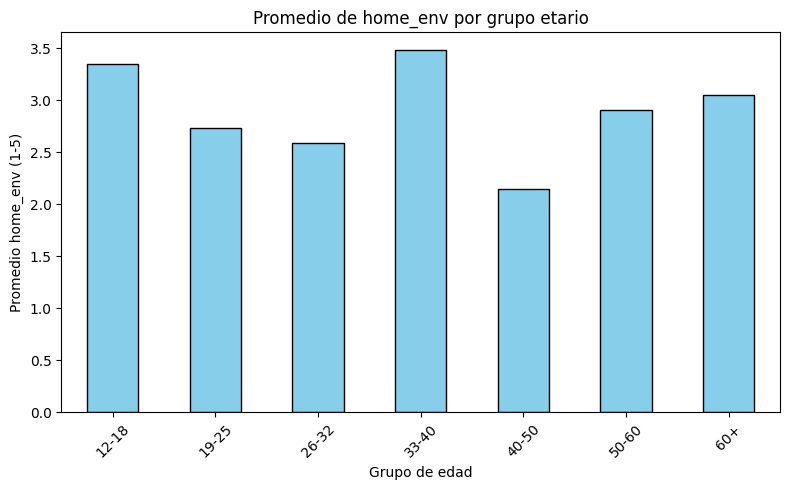

In [ ]:
#gráfico de barras: promedio de home_env por grupo etario

# Agrupamos los datos por la variable "age" (grupo de edad)
# y calculamos el promedio de "home_env" (comodidad en casa, escala 1-5)
promedios = df.groupby("age")["home_env"].mean()

# Configuramos la figura y el tamaño del gráfico
plt.figure(figsize=(8,5))

# Creamos un gráfico de barras con los promedios calculados
#   - kind="bar": gráfico de barras
#   - color="skyblue": color de las barras
#   - edgecolor="black": contorno negro para las barras
promedios.plot(kind="bar", color="skyblue", edgecolor="black")

# Añadimos título y etiquetas a los ejes
plt.title("Promedio de home_env por grupo etario")
plt.xlabel("Grupo de edad")
plt.ylabel("Promedio home_env (1-5)")

# Rotamos etiquetas del eje X para mayor legibilidad
plt.xticks(rotation=45)

# Ajustamos el diseño para evitar que se encimen los textos
plt.tight_layout()

# Guardamos el gráfico en la carpeta outputs como archivo PNG
plt.savefig("outputs/grafico_home_env.png")

# Mostramos el gráfico en pantalla dentro del notebook
plt.show()



### Interpretación de los resultados.

12–18 años (3.3):
Los más jóvenes en edad escolar se sienten relativamente cómodos trabajando desde casa, con un valor por encima de la media general.

19–25 años (2.7):
Los estudiantes universitarios o adultos jóvenes muestran menor comodidad en casa, posiblemente por falta de condiciones adecuadas (espacio, recursos, distracciones).

26–32 años (2.5):
Este grupo tiene el nivel de comodidad más bajo junto con el de 40–50. Puede estar relacionado con que muchos ya son profesionales jóvenes con cargas laborales exigentes y dificultades para separar trabajo y hogar.

33–40 años (3.5):
Este es el grupo con mayor comodidad reportada. Podría deberse a mayor estabilidad laboral y mejores condiciones en el hogar para el teletrabajo.

40–50 años (2.2):
Es el grupo con menor comodidad trabajando en casa. Esto puede reflejar dificultades de adaptación tecnológica o la incompatibilidad del trabajo con el hogar.

50–60 años (2.8):
Su comodidad es intermedia, un poco más alta que los jóvenes adultos, pero sin llegar al nivel de los de 33–40 o los más jóvenes.

60+ años (3.0):
Los mayores de 60 reportan un nivel aceptable de comodidad, más alto que los de 40–50, lo que sugiere que algunos pudieron adaptarse mejor de lo esperado.

- Comparación entre grupos

El grupo 33–40 años (3.5) es el más cómodo trabajando en casa.

El grupo 40–50 años (2.2) es el menos cómodo, mostrando una clara brecha respecto a los demás.

Jóvenes (12–18) y mayores (60+) se ubican en niveles relativamente altos de comodidad (~3.0 o más).

Adultos jóvenes (19–32) presentan valores bajos (2.5–2.7), probablemente por condiciones laborales menos favorables.
